### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
# Importaciones necesarias para toda la práctica
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score,
                             f1_score, precision_score, recall_score)
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")

print("Importaciones completadas correctamente ✓")

Importaciones completadas correctamente ✓


### 1. Carga del dataset

In [2]:
# El separador del CSV es ";" (punto y coma)
df = pd.read_csv(r"D:\The bridge\DS-Online-Hugo-Sanz\04_Machine_Learning\Sprint_11\Unidad_01_ML_Supervisado_Arboles_de_Decision\03_Practica_Obligatoria\data\bank-full.csv", sep=";")

print("Forma del dataset:", df.shape)
df.head()

Forma del dataset: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


### 2. Identificar el target y analizar su distribución

La columna **`y`** es el target: indica si el cliente contrató el depósito (`yes`) o no (`no`).

y
no     39922
yes     5289
Name: count, dtype: int64

Porcentaje:
y
no     88.3 %
yes    11.7 %
Name: proportion, dtype: object


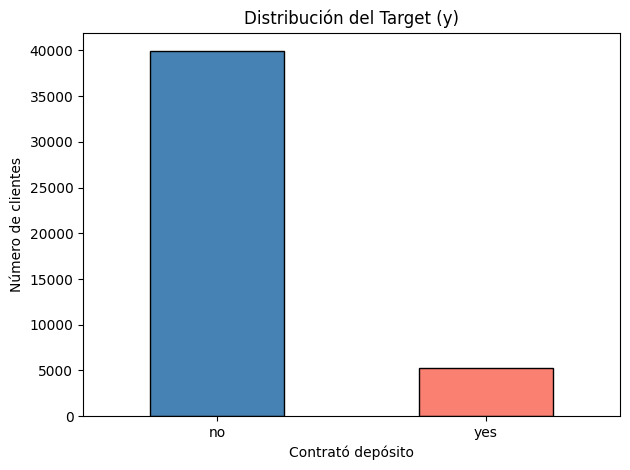

In [3]:
# Distribución del target
print(df["y"].value_counts())
print()
print("Porcentaje:")
print(df["y"].value_counts(normalize=True).mul(100).round(1).astype(str) + " %")

# Gráfico de barras
df["y"].value_counts().plot(kind="bar", color=["steelblue", "salmon"], edgecolor="black")
plt.title("Distribución del Target (y)")
plt.xlabel("Contrató depósito")
plt.ylabel("Número de clientes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observación:** El dataset está claramente **desbalanceado**: sólo ~11.7% de los clientes dijo `yes`. Por eso usaremos **F1** (no solo accuracy) para evaluar los modelos.

### 3. Limpieza y preparación de los datos

In [4]:
# Comprobamos si hay valores nulos
print("Nulos por columna:")
print(df.isnull().sum())
print()
print("Tipos de datos:")
print(df.dtypes)

Nulos por columna:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Tipos de datos:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object


In [5]:
# Codificamos las variables categóricas con LabelEncoder
# (convertimos texto a números para que el árbol pueda trabajar con ellas)
df_model = df.copy()

columnas_categoricas = df_model.select_dtypes(include="object").columns.tolist()
print("Columnas categóricas a codificar:", columnas_categoricas)

le = LabelEncoder()
for col in columnas_categoricas:
    df_model[col] = le.fit_transform(df_model[col])

df_model.head()

Columnas categóricas a codificar: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,4,1,2,0,2143,1,0,2,5,8,261,1,-1,0,3,0
1,44,9,2,1,0,29,1,0,2,5,8,151,1,-1,0,3,0
2,33,2,1,1,0,2,1,1,2,5,8,76,1,-1,0,3,0
3,47,1,1,3,0,1506,1,0,2,5,8,92,1,-1,0,3,0
4,33,11,2,3,0,1,0,0,2,5,8,198,1,-1,0,3,0


### 4. Separación train / test

In [6]:
# Separamos features (X) y target (y)
X = df_model.drop(columns="y")
y = df_model["y"]

# 80% entrenamiento, 20% test
# stratify=y -> mantiene la misma proporción de clases en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas")
print()
print("Distribución target en train:")
print(y_train.value_counts())

Train: 36168 filas | Test: 9043 filas

Distribución target en train:
y
0    31937
1     4231
Name: count, dtype: int64


### 5. Mini-EDA (exploración rápida sobre train)

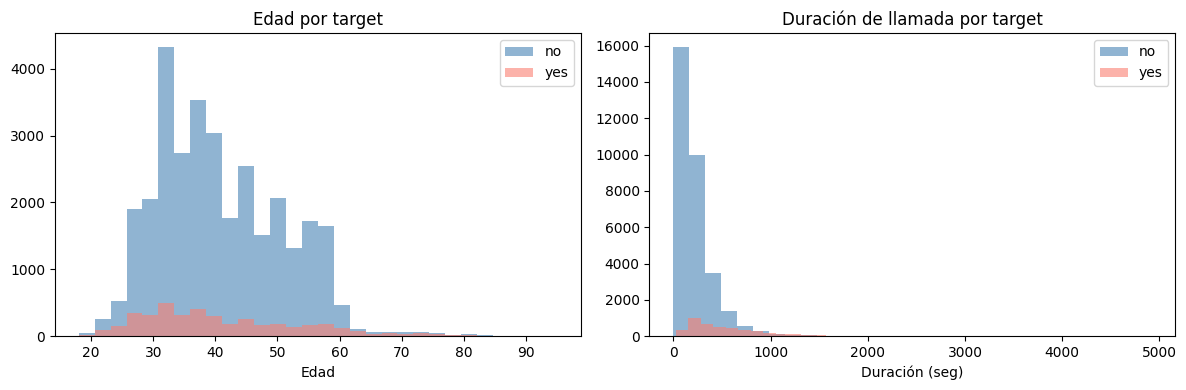

In [7]:
# Distribución de edad y duración de llamada según el target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Unimos X_train con y_train para poder agrupar
train_df = X_train.copy()
train_df["y"] = y_train.values

# Histogramas: 0 = no contrató, 1 = sí contrató
for val, label, color in zip([0, 1], ["no", "yes"], ["steelblue", "salmon"]):
    subset = train_df[train_df["y"] == val]
    axes[0].hist(subset["age"], bins=30, alpha=0.6, label=label, color=color)
    axes[1].hist(subset["duration"], bins=30, alpha=0.6, label=label, color=color)

axes[0].set_title("Edad por target")
axes[0].set_xlabel("Edad")
axes[0].legend()

axes[1].set_title("Duración de llamada por target")
axes[1].set_xlabel("Duración (seg)")
axes[1].legend()

plt.tight_layout()
plt.show()

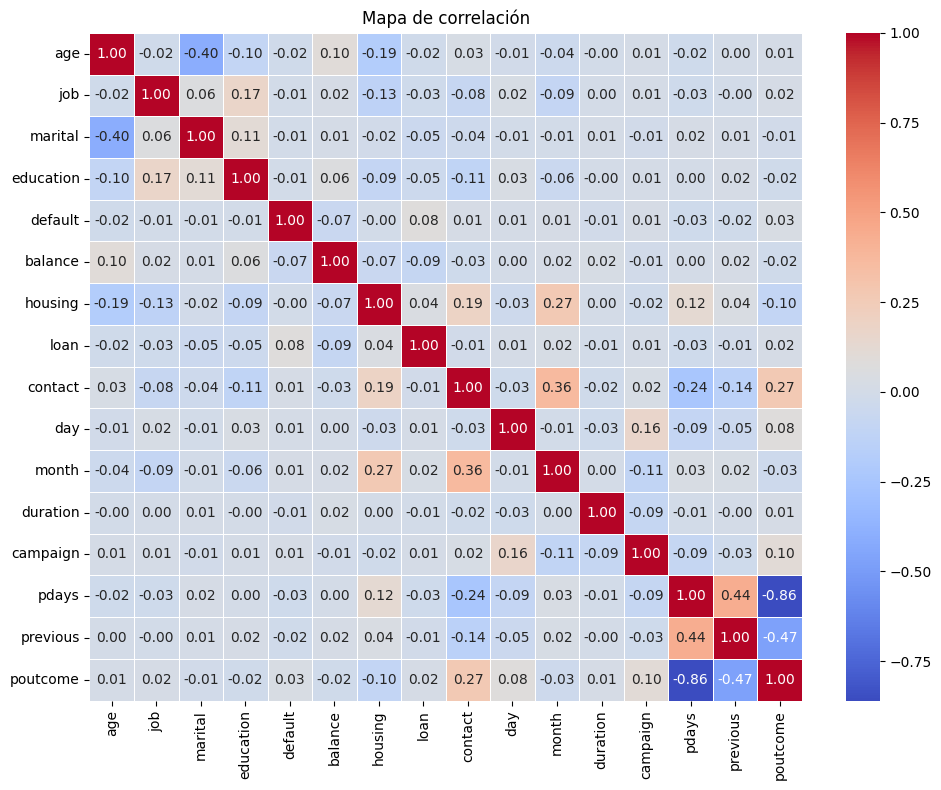

In [8]:
# Mapa de correlación entre variables numéricas
plt.figure(figsize=(10, 8))
sns.heatmap(X_train.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Mapa de correlación")
plt.tight_layout()
plt.show()

### 6. Árbol de Decisión inicial (sin optimizar)

Entrenamos primero un árbol con los parámetros por defecto para tener un punto de partida (*baseline*).

In [9]:
# Árbol con parámetros por defecto
dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train, y_train)

y_pred_base = dt_base.predict(X_test)

print("=== Árbol de Decisión BASE ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_base):.4f}")
print(f"F1 (yes):  {f1_score(y_test, y_pred_base):.4f}")
print()
print(classification_report(y_test, y_pred_base, target_names=["no", "yes"]))

=== Árbol de Decisión BASE ===
Accuracy:  0.8769
F1 (yes):  0.4767

              precision    recall  f1-score   support

          no       0.93      0.93      0.93      7985
         yes       0.47      0.48      0.48      1058

    accuracy                           0.88      9043
   macro avg       0.70      0.70      0.70      9043
weighted avg       0.88      0.88      0.88      9043



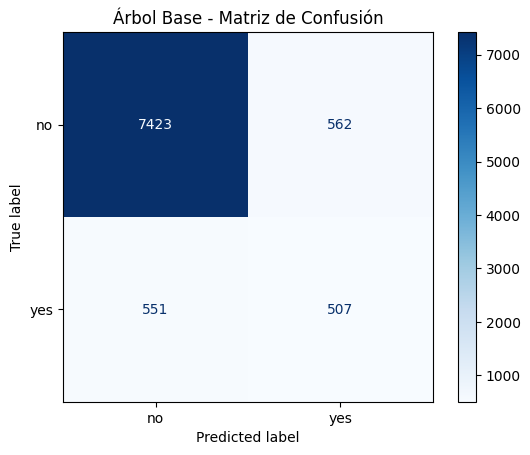

In [10]:
# Matriz de confusión del árbol base
cm = confusion_matrix(y_test, y_pred_base)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["no", "yes"])
disp.plot(cmap="Blues")
plt.title("Árbol Base - Matriz de Confusión")
plt.show()

### 7. Optimización de hiperparámetros con GridSearchCV

Probamos distintas combinaciones de hiperparámetros del árbol:
- **`max_depth`**: profundidad máxima → controla el sobreajuste
- **`min_samples_split`**: mínimo de muestras para dividir un nodo
- **`min_samples_leaf`**: mínimo de muestras en una hoja
- **`criterion`**: función para medir la impureza (gini o entropy)

Usamos **F1** como métrica de scoring porque el dataset está desbalanceado.

In [11]:
# Grid de hiperparámetros
param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [10, 20, 50],
    "min_samples_leaf": [5, 10, 20],
    "criterion": ["gini", "entropy"]
}

# GridSearchCV con 5-fold cross-validation
dt = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring="f1",     # F1 por el desbalanceo
    cv=5,
    n_jobs=-1,        # usa todos los núcleos del procesador
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Mejores hiperparámetros encontrados:")
print(grid_search.best_params_)
print(f"\nMejor F1 en validación cruzada: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 90 candidates, totalling 450 fits
Mejores hiperparámetros encontrados:
{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 20, 'min_samples_split': 50}

Mejor F1 en validación cruzada: 0.5013


In [12]:
# Evaluamos el mejor árbol sobre test
dt_best = grid_search.best_estimator_
y_pred_best = dt_best.predict(X_test)

print("=== Árbol de Decisión OPTIMIZADO ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_best):.4f}")
print(f"F1 (yes):  {f1_score(y_test, y_pred_best):.4f}")
print()
print(classification_report(y_test, y_pred_best, target_names=["no", "yes"]))

=== Árbol de Decisión OPTIMIZADO ===
Accuracy:  0.8987
F1 (yes):  0.5086

              precision    recall  f1-score   support

          no       0.93      0.96      0.94      7985
         yes       0.59      0.45      0.51      1058

    accuracy                           0.90      9043
   macro avg       0.76      0.70      0.73      9043
weighted avg       0.89      0.90      0.89      9043



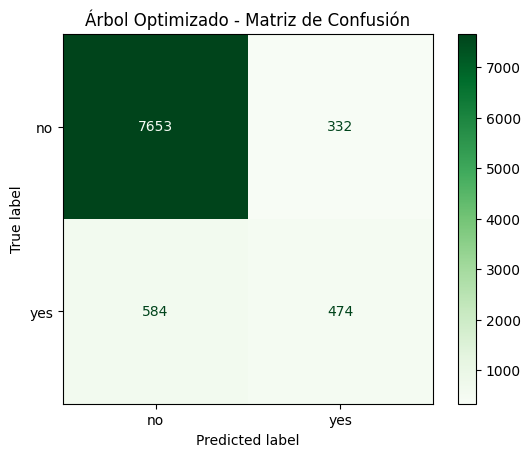

In [13]:
# Matriz de confusión del árbol optimizado
cm_best = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=["no", "yes"])
disp.plot(cmap="Greens")
plt.title("Árbol Optimizado - Matriz de Confusión")
plt.show()

### 8. Visualización del árbol optimizado (primeros niveles)

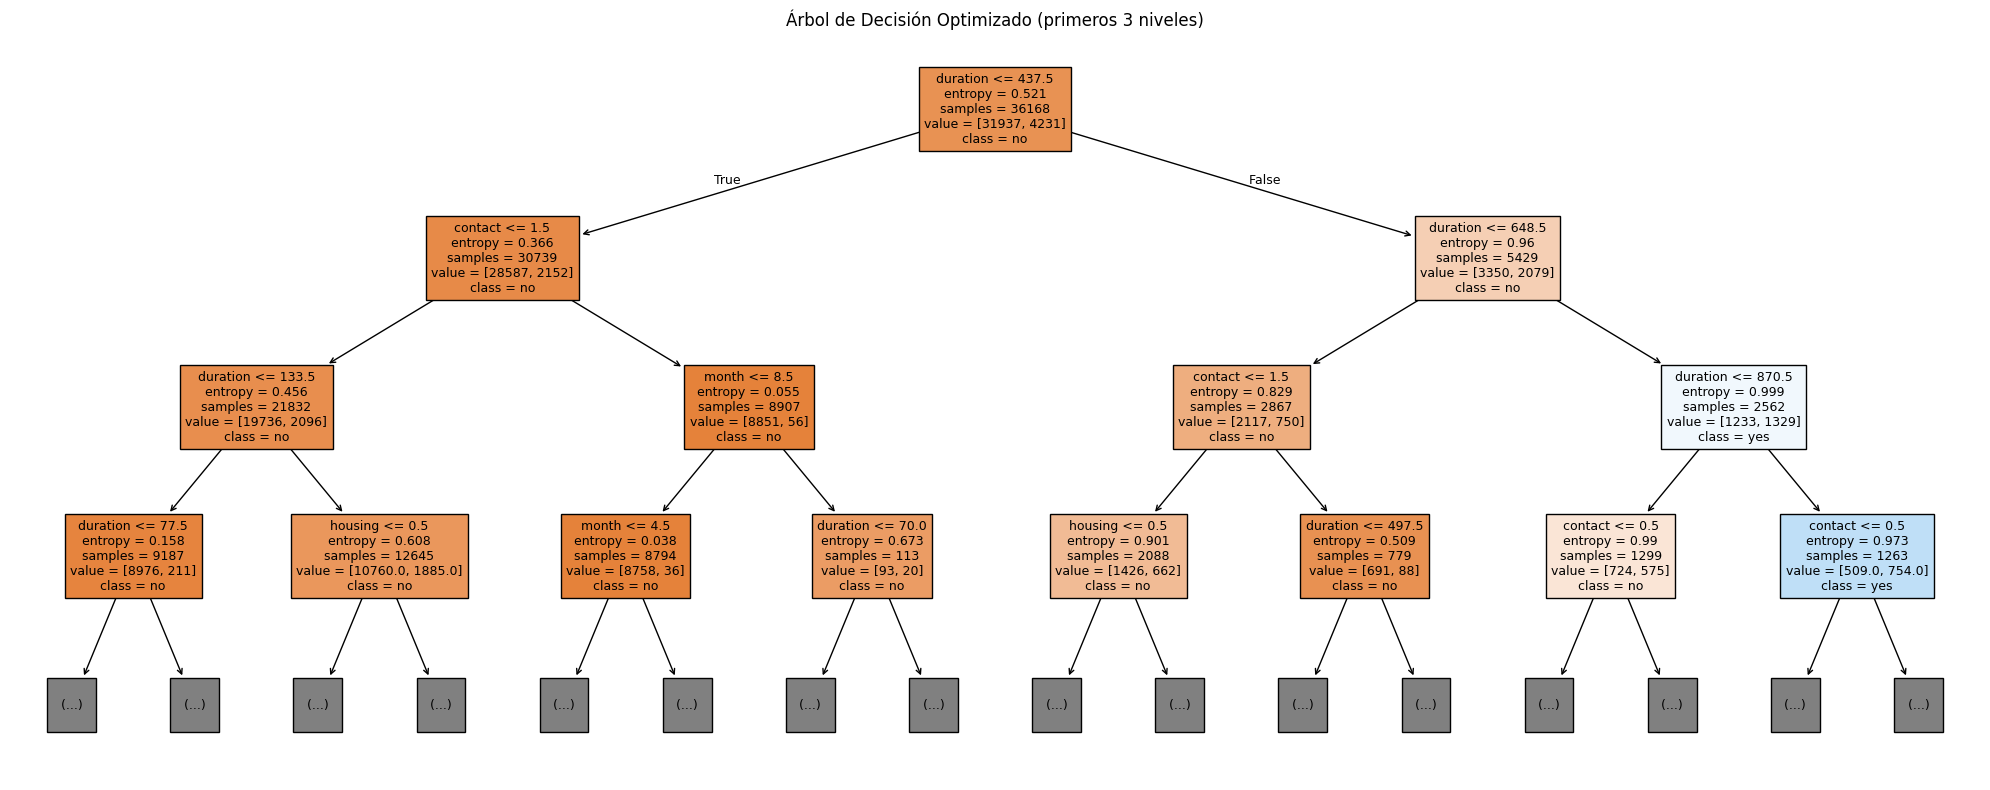

In [14]:
plt.figure(figsize=(20, 8))
plot_tree(
    dt_best,
    feature_names=X.columns.tolist(),
    class_names=["no", "yes"],
    filled=True,
    max_depth=3,        # sólo mostramos 3 niveles para que sea legible
    fontsize=9
)
plt.title("Árbol de Decisión Optimizado (primeros 3 niveles)")
plt.tight_layout()
plt.show()

### 9. Importancia de las variables

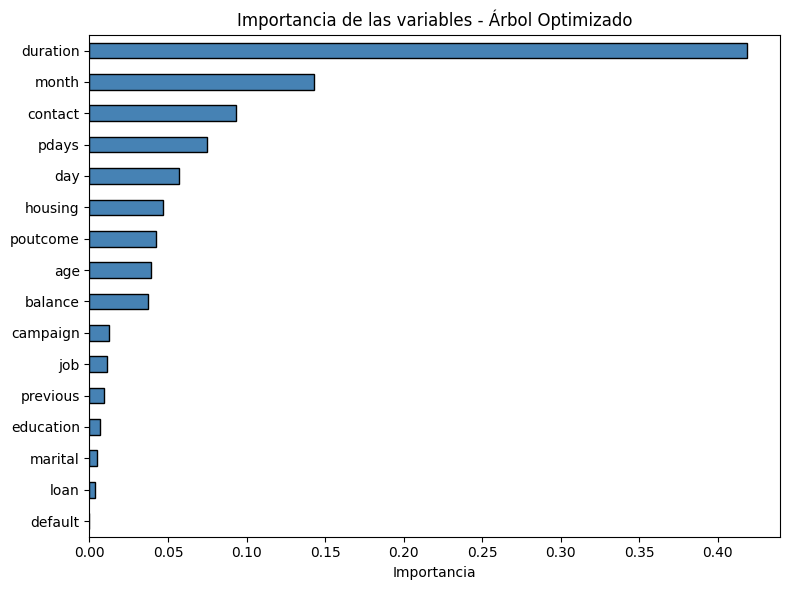

In [15]:
importancias = pd.Series(dt_best.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=True)

importancias.plot(kind="barh", figsize=(8, 6), color="steelblue", edgecolor="black")
plt.title("Importancia de las variables - Árbol Optimizado")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

### 10. Comparación con Regresión Logística (sin optimizar)

In [16]:
# Regresión Logística sin optimizar (baseline alternativo)
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("=== Regresión Logística (sin optimizar) ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"F1 (yes):  {f1_score(y_test, y_pred_lr):.4f}")
print()
print(classification_report(y_test, y_pred_lr, target_names=["no", "yes"]))

=== Regresión Logística (sin optimizar) ===
Accuracy:  0.8900
F1 (yes):  0.2978

              precision    recall  f1-score   support

          no       0.90      0.98      0.94      7985
         yes       0.59      0.20      0.30      1058

    accuracy                           0.89      9043
   macro avg       0.75      0.59      0.62      9043
weighted avg       0.87      0.89      0.87      9043



In [17]:
# Tabla comparativa de los 3 modelos
modelos = {
    "Árbol Base": y_pred_base,
    "Árbol Optimizado": y_pred_best,
    "Regresión Logística": y_pred_lr
}

resultados = []
for nombre, predicciones in modelos.items():
    resultados.append({
        "Modelo": nombre,
        "Accuracy": round(accuracy_score(y_test, predicciones), 4),
        "F1 (yes)": round(f1_score(y_test, predicciones), 4),
        "Precision (yes)": round(precision_score(y_test, predicciones), 4),
        "Recall (yes)": round(recall_score(y_test, predicciones), 4)
    })

tabla = pd.DataFrame(resultados).set_index("Modelo")
print(tabla.to_string())

                     Accuracy  F1 (yes)  Precision (yes)  Recall (yes)
Modelo                                                                
Árbol Base             0.8769    0.4767           0.4743        0.4792
Árbol Optimizado       0.8987    0.5086           0.5881        0.4480
Regresión Logística    0.8900    0.2978           0.5877        0.1994


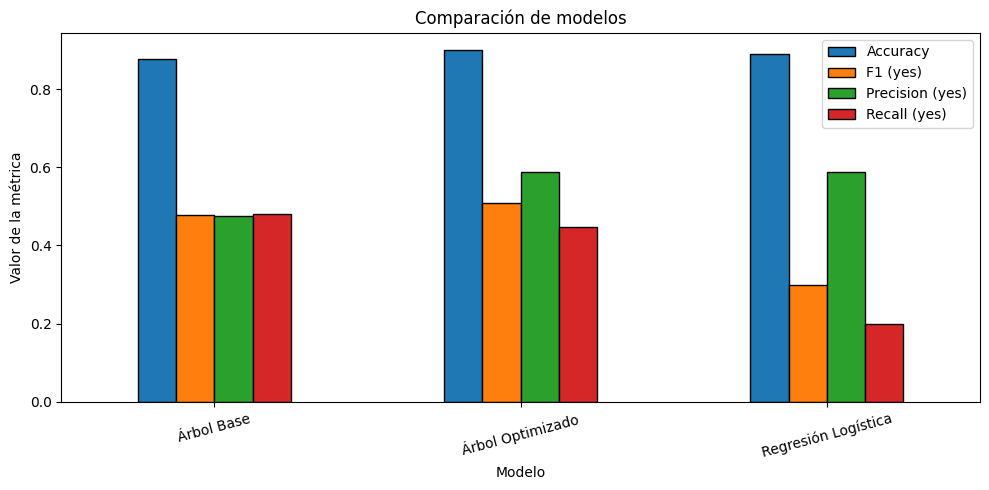

In [18]:
# Gráfico comparativo
tabla.plot(kind="bar", figsize=(10, 5), edgecolor="black")
plt.title("Comparación de modelos")
plt.ylabel("Valor de la métrica")
plt.xticks(rotation=15)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

### 11. Evaluación final y valoración

**Conclusiones:**

- El dataset está **muy desbalanceado** (~88% `no`, ~12% `yes`), por lo que la accuracy sola puede engañar. Un modelo que siempre prediga `no` tendría ~88% de accuracy sin ser útil para la campaña.
- El **árbol optimizado** mejora respecto al base en F1 y recall para la clase `yes`, que es la que más interesa al banco (queremos detectar a los clientes que SÍ van a contratar).
- La **Regresión Logística** sin optimizar suele ser un buen punto de comparación: es más simple pero a veces compite bien con modelos más complejos.
- La variable más importante según el árbol es **`duration`** (duración de la llamada en segundos), lo que tiene mucho sentido: si la llamada dura más es señal de que el cliente está interesado en el producto.
- Para mejorar el modelo en el futuro se podría:
  - Aplicar técnicas de balanceo como SMOTE o usar `class_weight="balanced"`
  - Probar modelos más potentes como Random Forest o XGBoost
  - Afinar aún más el grid de hiperparámetros
